# 01 — Financial data

This notebook creates the canonical return matrix. Put a real adjusted-price CSV at `data/raw/market_prices.csv` with dates in the first column and one positive price column per asset. Until that file exists, the notebook uses deterministic demo prices only to test the pipeline.

In [1]:
import sys
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from innovcal.data import make_demo_prices, prices_to_log_returns

In [2]:
RAW_PATH = ROOT / 'data' / 'raw' / 'market_prices.csv'
OUTPUT_PATH = ROOT / 'data' / 'processed' / 'financial_returns.csv'

if RAW_PATH.exists():
    prices = pd.read_csv(RAW_PATH, index_col=0, parse_dates=True)
    data_source = 'real CSV'
else:
    prices = make_demo_prices(n_observations=600, n_assets=4, seed=123)
    data_source = 'DEMO — not empirical evidence'

returns = prices_to_log_returns(prices)
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
returns.to_csv(OUTPUT_PATH)
print(data_source, prices.shape, returns.shape)
returns.describe().T

DEMO — not empirical evidence (600, 4) (599, 4)


/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/data/financial.py:88: RuntimeWarning: divide by zero encountered in matmul
  returns = rng.multivariate_normal(
/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/data/financial.py:88: RuntimeWarning: overflow encountered in matmul
  returns = rng.multivariate_normal(
/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/data/financial.py:88: RuntimeWarning: invalid value encountered in matmul
  returns = rng.multivariate_normal(


,count,mean,std,min,25%,50%,75%,max
Asset_1,599.0,0.000005,0.008077,-0.024473,-0.005233,0.000110,0.005031,0.021508
Asset_2,599.0,-0.000515,0.010312,-0.031313,-0.007737,-0.000219,0.006387,0.028702
Asset_3,599.0,-0.000022,0.012108,-0.038432,-0.007984,0.000059,0.007731,0.040705
Asset_4,599.0,0.000591,0.014131,-0.048366,-0.008919,0.000276,0.009983,0.049224


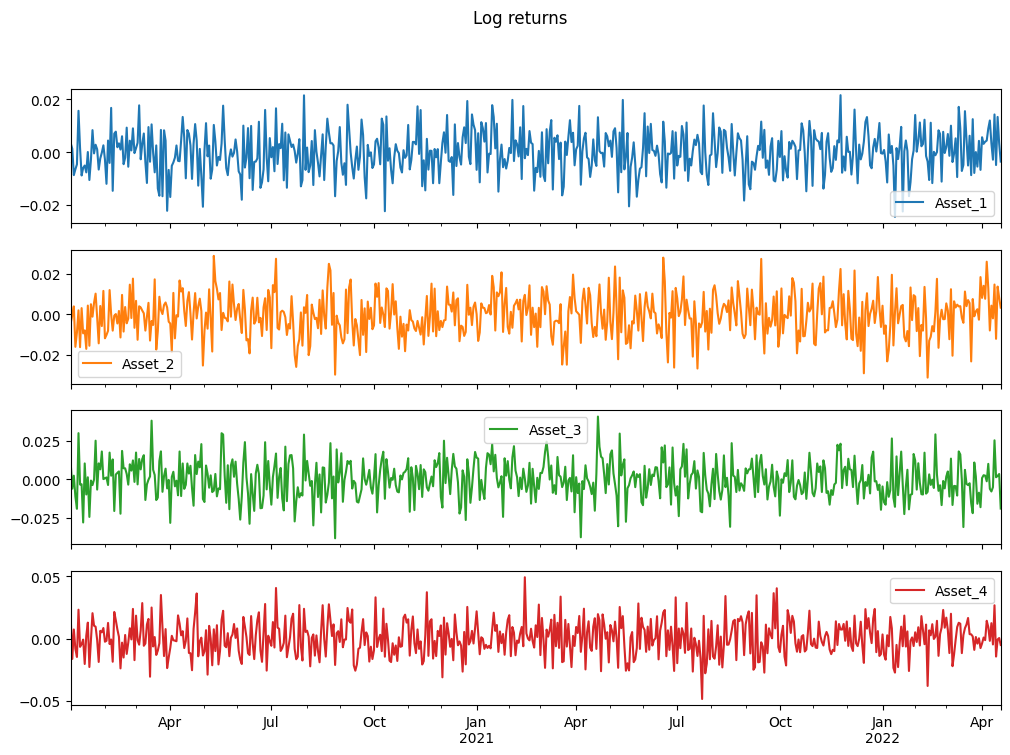

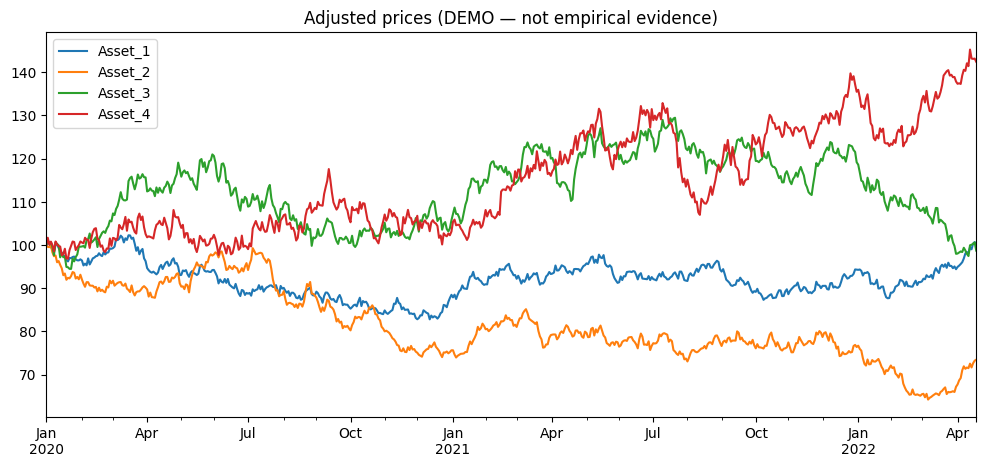

In [3]:
axes = returns.plot(subplots=True, figsize=(12, 8), title='Log returns')
prices.plot(figsize=(12, 5), title=f'Adjusted prices ({data_source})');

Before treating results as empirical evidence, document asset selection, frequency, date range, missing-data handling, and the adjusted-price source.